# Importing Libraries

In [1]:
import sys, os
sys.path.append(os.pardir)
sys.path.append('./')
import numpy as np
import matplotlib.pyplot as plt

import cv2
import skimage.transform as sktrans
import skimage.filters as skfilt

#Import tensorflow & tf.keras library
import tensorflow as tf
from tensorflow import keras

from WB_TSX import read_pickle, multiclass_sparse_weighted_cross_entropy, DataGenerator,get_unet

2025-01-13 07:03:32.773010: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-13 07:03:32.806481: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-13 07:03:32.806510: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-13 07:03:32.806533: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-13 07:03:32.813172: I tensorflow/core/platform/cpu_feature_g

# Importing Test Data

In [2]:
my_path = "/workspace/pytorch_unet/python-programs/Tensor/02_IITP/"  # 경로 설정

key_sat = "TSX" 
#loading dataset
data = read_pickle(my_path + "/TSX_ai_data.pkl") # data for training a model


x_test = np.array(data[key_sat]["test"]["image"])
t_test = np.array(data[key_sat]["test"]["label"])

N_test  = x_test.shape[0]

t_test = t_test.astype('uint8')
#printing the shapes of the vectors
print('shape of test data:     '  + str(x_test.shape))
print('shape of test label:    '  + str(t_test.shape))

shape of test data:     (309, 512, 512, 1)
shape of test label:    (309, 512, 512)


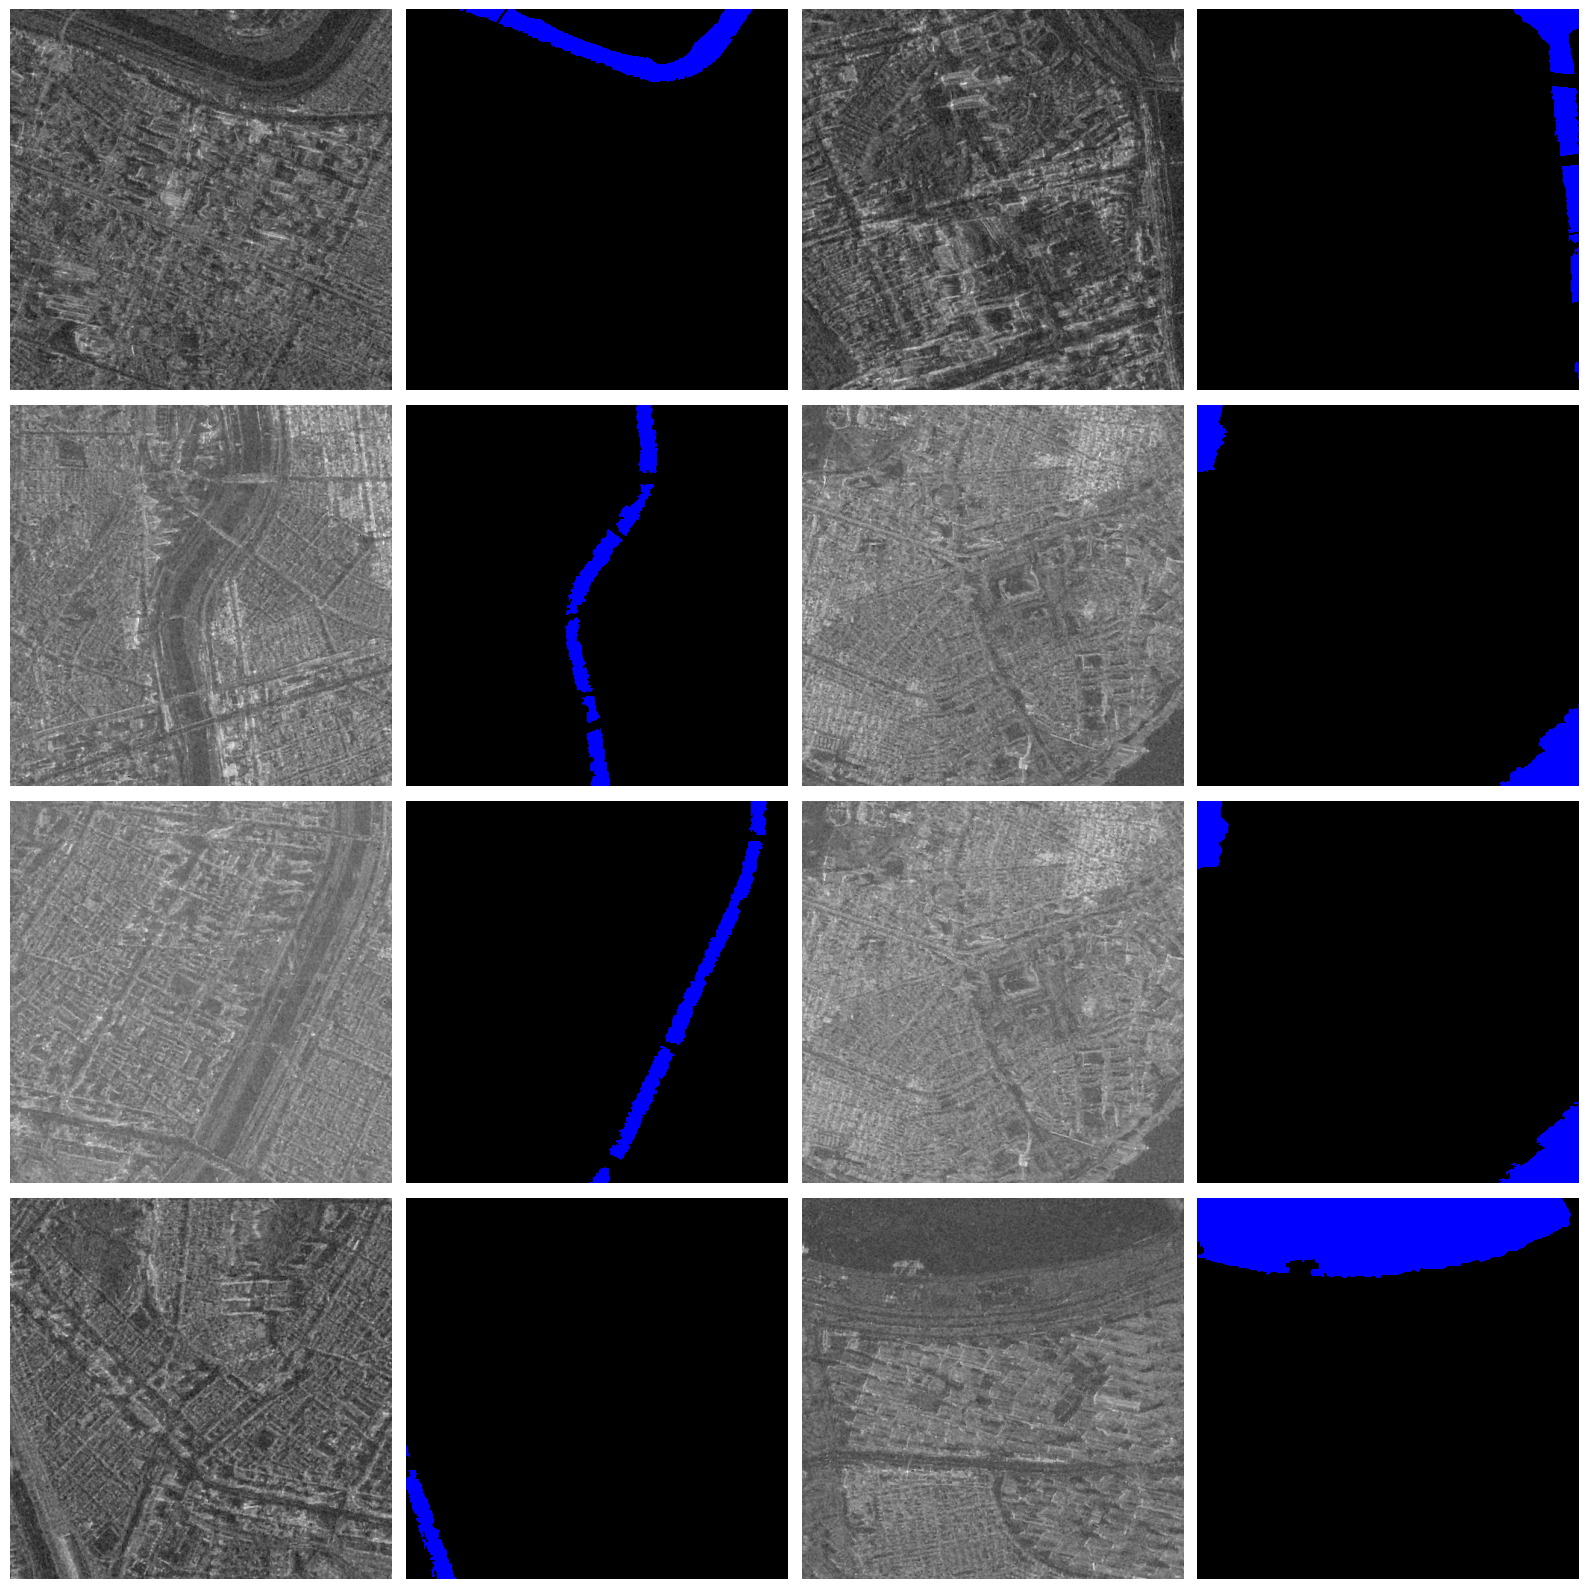

In [3]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# 컬러맵 정의
cmap = ListedColormap(['black', 'blue'])

plt.figure(figsize=(16, 16))

# 4x4 시각화를 위한 인덱스 배열 생성
random_indices = np.random.choice(x_test.shape[0], size=8, replace=False)  # 8개의 랜덤 인덱스 생성 (한 행당 2개씩)

for i in range(4):  # 4행
    for j in range(4):  # 4열
        idx = i * 2 + j // 2  # 같은 행에서 짝수 열과 홀수 열이 동일한 인덱스를 공유
        plt.subplot(4, 4, i * 4 + j + 1)  # 4행 4열 서브플롯 설정
        if j % 2 == 0:
            plt.imshow(x_test[random_indices[idx]], cmap='gray')  # x_train 이미지 시각화
        else:
            plt.imshow(t_test[random_indices[idx]], cmap=cmap)  # t_train 클래스 시각화
        plt.axis('off')  # 축 제거

plt.tight_layout()
plt.show()


#  Setting up Model Hyperparameters & Load U-Net

In [4]:
# setup model hyperparameters
lr = 0.0001
mini_batch=10
preTrained = False
param_file = my_path + "/checkpoint/TSX_Unet_Commit.h5"
class_weights = [0.15,0.85]
fbeta = fbeta0; IoU = IoU0

In [7]:
mirrored_strategy = tf.distribute.MirroredStrategy(devices=["/gpu:0","/gpu:1","/gpu:2"])
with mirrored_strategy.scope():
    model  = get_unet(input_size=(x_test.shape[1],x_test.shape[2],x_test.shape[3]),outputsize=2,nfilters=[64, 128, 256, 512])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr) ,loss=multiclass_sparse_weighted_cross_entropy(class_weights=class_weights), metrics='accuracy')
model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localho

# Evaluating Model Performance

In [8]:
model.load_weights(param_file)

In [9]:
print("### Performance Evaluation of Model Trained with Augmentation ###")
model.evaluate(x_test,t_test, verbose=0)

### Performance Evaluation of Model Trained with Augmentation ###


2025-01-13 07:04:03.766412: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-01-13 07:04:03.794523: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-01-13 07:04:03.832925: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600


[0.006521380972117186, 0.9786453247070312]

# Inferring from Test Data

In [10]:
Nt_test = t_test.shape[0]
pred_test  = np.zeros((Nt_test,t_test.shape[1],t_test.shape[2],2))

for i in range(Nt_test//mini_batch):
    pred_test[mini_batch*i:mini_batch*(i+1)]= model.predict(x_test[mini_batch*i:mini_batch*(i+1)],verbose=0)

# Displaying and Saving Model Inference Results

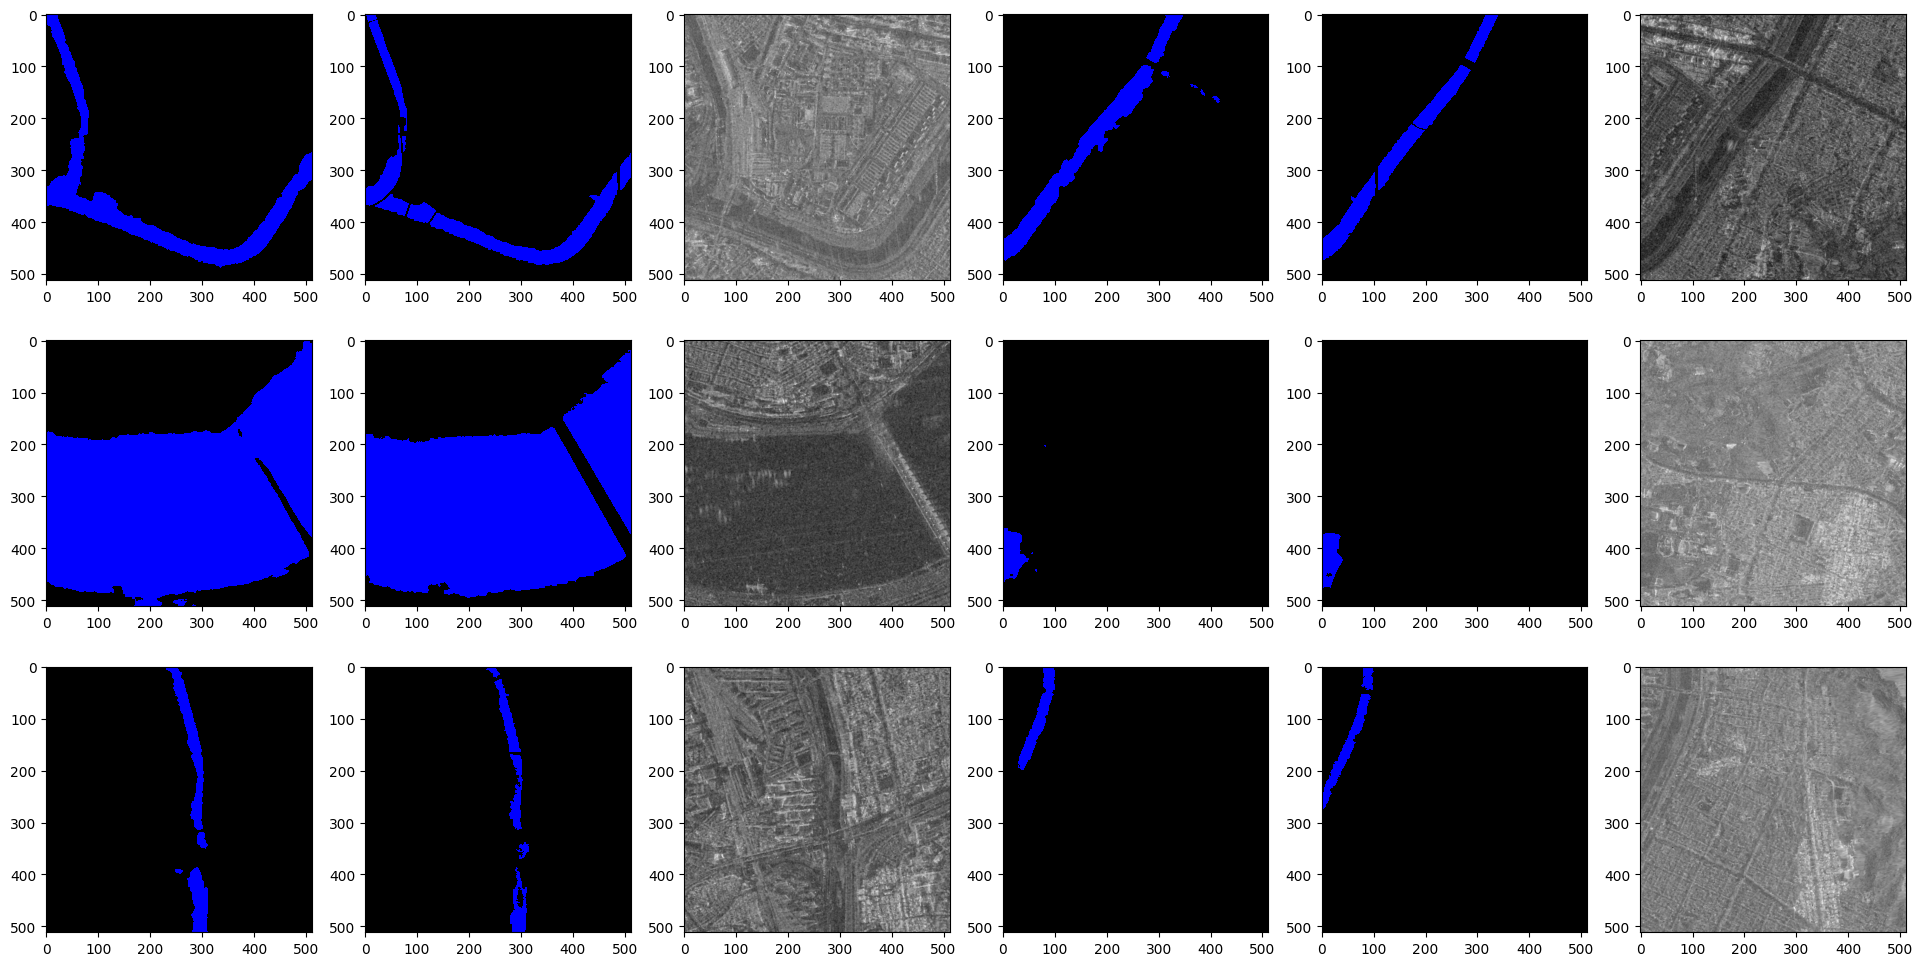

In [11]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['black','blue'])
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
class_names = ['Non-water','Water']

sel_num = np.random.randint(0,t_test.shape[0]-1,size=num_images)
param_file

# with aug
plt.figure(figsize=(4*3*num_cols, 4*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 3*num_cols, 3*i+1)
    plt.imshow(np.argmax(pred_test[sel_num[i]],axis=2),cmap=cmap)
    plt.subplot(num_rows, 3*num_cols, 3*i+2)
    plt.imshow(t_test[sel_num[i]],cmap=cmap)
    plt.subplot(num_rows, 3*num_cols, 3*i+3)
    plt.imshow(x_test[sel_num[i]],cmap='gray')

plt.show()

# Model Performance Evaluation

In [15]:
# 필요한 라이브러리 임포트
from sklearn.metrics import confusion_matrix
import numpy as np

# 혼동 행렬 생성
Cm = confusion_matrix(t_test.reshape(-1), np.argmax(pred_test, axis=3).reshape(-1))

# 수체(Water)와 비수체(Non-water) 지표 계산
# Water (class 1)
IoU_water = Cm[1, 1] / (Cm[1, 1] + Cm[0, 1] + Cm[1, 0])
Precision_water = Cm[1, 1] / (Cm[1, 1] + Cm[0, 1])
Recall_water = Cm[1, 1] / (Cm[1, 1] + Cm[1, 0])
F1_score_water = 2 * (Precision_water * Recall_water) / (Precision_water + Recall_water)

# Non-water (class 0)
IoU_non_water = Cm[0, 0] / (Cm[0, 0] + Cm[1, 0] + Cm[0, 1])
Precision_non_water = Cm[0, 0] / (Cm[0, 0] + Cm[1, 0])
Recall_non_water = Cm[0, 0] / (Cm[0, 0] + Cm[0, 1])
F1_score_non_water = 2 * (Precision_non_water * Recall_non_water) / (Precision_non_water + Recall_non_water)

# 정확도 계산
Accuracy = (Cm[0, 0] + Cm[1, 1]) / np.sum(Cm)

# 결과 출력
print("******************* Performance Results *******************")
print(f"Accuracy = {Accuracy:.4f}")

print("\nWater (Class 1) Metrics:")
print(f"IoU (Water) = {IoU_water:.4f}")
print(f"Precision (Water) = {Precision_water:.4f}")
print(f"Recall (Water) = {Recall_water:.4f}")
print(f"F1-score (Water) = {F1_score_water:.4f}")

print("\nNon-water (Class 0) Metrics:")
print(f"IoU (Non-water) = {IoU_non_water:.4f}")
print(f"Precision (Non-water) = {Precision_non_water:.4f}")
print(f"Recall (Non-water) = {Recall_non_water:.4f}")
print(f"F1-score (Non-water) = {F1_score_non_water:.4f}")


******************* Performance Results *******************
Accuracy = 0.9777

Water (Class 1) Metrics:
IoU (Water) = 0.8386
Precision (Water) = 0.8615
Recall (Water) = 0.9694
F1-score (Water) = 0.9122

Non-water (Class 0) Metrics:
IoU (Non-water) = 0.9748
Precision (Non-water) = 0.9958
Recall (Non-water) = 0.9789
F1-score (Non-water) = 0.9873


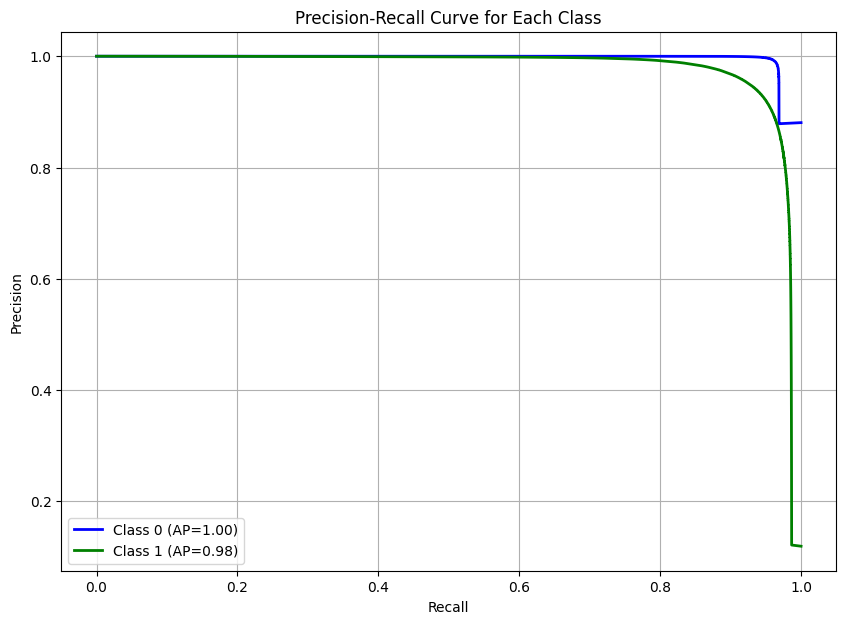

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

# 예제 데이터 (t_test: 실제 라벨, pred_test: 예측 확률)
# t_test: (N, H, W) 크기의 정답 라벨
# pred_test: (N, H, W, C) 크기의 예측 확률, C는 클래스 수

# Flattening the data for calculation
t_test_flat = t_test.reshape(-1)  # 정답 라벨
pred_test_flat = pred_test.reshape(-1, pred_test.shape[-1])  # 예측 확률

# 클래스별 Precision-Recall 및 AP 계산
precision = dict()
recall = dict()
average_precision = dict()
n_classes = pred_test.shape[-1]  # 클래스 수

# 각 클래스에 대한 PR 곡선 및 AP 계산
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(t_test_flat == i, pred_test_flat[:, i])
    average_precision[i] = average_precision_score(t_test_flat == i, pred_test_flat[:, i])

# PR-curve 그리기
plt.figure(figsize=(10, 7))
colors = ['b', 'g']  

for i in range(n_classes):
    plt.plot(recall[i], precision[i], color=colors[i], lw=2,
             label=f'Class {i} (AP={average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()
